# ⚠️ PREVIEW NOTEBOOK — Pipeline Not Yet Trained

This notebook is a **preview / dry-run** of the full CNN pipeline below. It shows the real code — architecture, preprocessing, callbacks, everything — plus the *expected shape and format* of every output (data summaries, training log, evaluation metrics, plots), so the approach can be reviewed **before** committing GPU time to the full training run on the full dataset.

**Every number, training log, and metric shown here is an illustrative placeholder.** They were generated to be internally consistent with each other and with the dataset's known class imbalance (matching the class distribution already seen in the baseline-model notebook), but they are **not** the output of an actual training run — no GPU has been used and the model has not been trained yet. Real numbers will replace these once the notebook is executed end-to-end.

The code itself is the real, intended implementation and will run as-is once data + GPU are available.

# CNN-Based NIDS — 4-Class Classification

**Architecture improvements over the original proposed design:**

| Issue in Original | Fix Applied |
|---|---|
| Output = 1 neuron (binary) | Output = 4 neurons + Softmax |
| Single Conv layer | 3 Conv1D blocks (64→128→256 filters) |
| No Dropout | Dropout(0.3) after every block |
| Dense(1024)→Dense(10) hard bottleneck | Dense(256)→Dense(128) gradual reduction |
| No residual connections | Skip connections in each block |
| Raw Flatten | GlobalAveragePooling (less overfitting) |
| CrossEntropy on imbalanced data | Focal Loss (suppresses easy-majority samples) |
| No LR scheduling | ReduceLROnPlateau + early stopping |

## 📦 Cell 1 — Install & Imports

In [ ]:
# Install dependencies if on Colab
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'tensorflow', 'scikit-learn', 'imbalanced-learn',
                'pandas', 'numpy', 'matplotlib', 'seaborn'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from imblearn.over_sampling import SMOTE
from collections import Counter

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print('=' * 60)
print('TensorFlow version :', tf.__version__)
print('GPU available      :', 'YES —' + str(gpus) if gpus else 'NO (CPU only)')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('  Memory growth enabled')
print('=' * 60)

TensorFlow version : 2.16.1
GPU available      : NO (CPU only)

## 📂 Cell 2 — Load & Clean Data

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [2]:
print('Loading data...')
t0 = time.time()

df = pd.read_parquet('part_01.parquet')

if 'Label' in df.columns:
    df = df.drop(columns='Label')

X_raw = df.drop(columns=['ClassLabel'])
y_raw = df['ClassLabel']

print(f'Raw shape : {df.shape}')
print(f'Classes   :\n{y_raw.value_counts()}')

# --- Clean ---
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.median())

# Drop constant columns
constant_cols = X_raw.columns[X_raw.nunique() == 1]
X_raw = X_raw.drop(columns=constant_cols)

# Cap outliers
Q1, Q3 = X_raw.quantile(0.25), X_raw.quantile(0.75)
IQR = Q3 - Q1
X_raw = X_raw.clip(lower=Q1 - 3*IQR, upper=Q3 + 3*IQR, axis=1)

print(f'\nCleaned shape: {X_raw.shape}')
print(f'✓ Done in {time.time()-t0:.1f}s')

Loading data...
Raw shape : (4581170, 80)
Classes   :
ClassLabel
Benign        3593095
DoS            816040
BruteForce      99050
Botnet          72985
Name: count, dtype: int64

Cleaned shape: (4581170, 76)
✓ Done in 24.6s

## ⚙️ Cell 3 — Feature Engineering

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [3]:
X = X_raw.copy()

if 'Fwd Packets/s' in X.columns and 'Bwd Packets/s' in X.columns:
    X['Fwd_Bwd_Packet_Ratio'] = X['Fwd Packets/s'] / (X['Bwd Packets/s'] + 1e-10)

if 'Total Fwd Packets' in X.columns and 'Total Backward Packets' in X.columns:
    X['Packet_Direction_Ratio'] = X['Total Fwd Packets'] / (X['Total Backward Packets'] + 1e-10)

if all(c in X.columns for c in ['Flow Duration','Total Fwd Packets','Total Backward Packets']):
    X['Avg_Duration_Per_Packet'] = X['Flow Duration'] / (
        X['Total Fwd Packets'] + X['Total Backward Packets'] + 1e-10)

length_cols = [c for c in X.columns if 'Packet Length' in c]
if len(length_cols) >= 2:
    X['Packet_Length_Variance_Custom'] = X[length_cols].var(axis=1)

print(f'Feature shape after engineering: {X.shape}')

Feature shape after engineering: (4581170, 80)

## 🎯 Cell 4 — Feature Selection

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [4]:
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)

print(f'Classes ({NUM_CLASSES}): {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Variance threshold
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X)
selected = X.columns[sel_var.get_support()].tolist()
print(f'After variance threshold: {len(selected)} features')

# MI top-50
print('Computing Mutual Information...')
sample_idx = np.random.RandomState(SEED).choice(len(X), min(30000, len(X)), replace=False)
mi_scores = mutual_info_classif(X[selected].iloc[sample_idx],
                                 y_enc[sample_idx], random_state=SEED)
mi_df = pd.DataFrame({'feature': selected, 'mi': mi_scores}).sort_values('mi', ascending=False)
top_mi = mi_df.head(50)['feature'].tolist()

# Drop high-correlation
corr_m = X[top_mi].corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
final_features = [f for f in top_mi if f not in to_drop]

X_sel = X[final_features].copy()
print(f'Final feature set: {X_sel.shape[1]} features')

Classes (4): {'Benign': 0, 'Botnet': 1, 'BruteForce': 2, 'DoS': 3}
After variance threshold: 68 features
Computing Mutual Information...
Final feature set: 37 features

## ✂️ Cell 5 — Split, Scale & Resample

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED)

# Hold out validation from train
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

# Scale
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training only
print(f'Before SMOTE: {Counter(y_train)}')
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
print(f'After  SMOTE: {Counter(y_train_res)}')

# Reshape for CNN: (samples, features, 1)
N_FEATURES = X_train_res.shape[1]
X_train_cnn = X_train_res.reshape(-1, N_FEATURES, 1)
X_val_cnn   = X_val_sc.reshape(-1, N_FEATURES, 1)
X_test_cnn  = X_test_sc.reshape(-1, N_FEATURES, 1)

# One-hot for training
y_train_oh = tf.keras.utils.to_categorical(y_train_res, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,       NUM_CLASSES)

print(f'\nCNN input shape: {X_train_cnn.shape}  →  (batch, {N_FEATURES}, 1)')
print('✓ Data ready for CNN')

Train: (3115196, 37)  Val: (549740, 37)  Test: (916234, 37)
Before SMOTE: Counter({0: 2443305, 3: 554907, 2: 67354, 1: 49630})
After  SMOTE: Counter({0: 2443305, 3: 2443305, 2: 2443305, 1: 2443305})

CNN input shape: (9773220, 37, 1)  →  (batch, 37, 1)
✓ Data ready for CNN

---
## 🏗️ Cell 6 — Build Improved CNN Architecture

```
Input(features, 1)
  │
  ├─ Conv1D(64, k=6) + BN + ReLU ──┐  Block 1 (+ residual projection)
  │  Conv1D(64, k=6) + BN + ReLU  ─┤
  │  MaxPool1D(2) + Dropout(0.3)   ─┘
  │
  ├─ Conv1D(128, k=4) + BN + ReLU ─┐  Block 2 (+ residual projection)
  │  Conv1D(128, k=4) + BN + ReLU ─┤
  │  MaxPool1D(2) + Dropout(0.3)  ─┘
  │
  ├─ Conv1D(256, k=3) + BN + ReLU ─┐  Block 3 (+ residual projection)
  │  Conv1D(256, k=3) + BN + ReLU ─┤
  │  GlobalAvgPool + Dropout(0.3) ─┘
  │
  ├─ Dense(256) + BN + ReLU + Dropout(0.4)
  ├─ Dense(128) + BN + ReLU + Dropout(0.3)
  └─ Dense(4) + Softmax
```

*(Parameter counts below are exact for this architecture, computed assuming the N_FEATURES=37 final feature count shown in the Cell 4 preview above.)*

In [6]:
def conv_block(x, filters, kernel_size, pool=True, dropout_rate=0.3):
    """Two Conv1D layers with BN + ReLU, optional MaxPool, residual connection."""
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Residual projection if channel dim changed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    if pool:
        x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def build_cnn(input_shape, num_classes):
    inp = Input(shape=input_shape, name='input')

    # Block 1 — wide receptive field (kernel=6, same as original proposal)
    x = conv_block(inp, filters=64,  kernel_size=6, pool=True,  dropout_rate=0.3)

    # Block 2 — medium receptive field
    x = conv_block(x,   filters=128, kernel_size=4, pool=True,  dropout_rate=0.3)

    # Block 3 — fine-grained features
    x = conv_block(x,   filters=256, kernel_size=3, pool=False, dropout_rate=0.3)

    # Global pooling (replaces raw Flatten — more generalisable)
    x = layers.GlobalAveragePooling1D()(x)

    # Fully-connected head
    x = layers.Dense(256, use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, use_bias=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inp, outputs=out, name='NIDS_CNN')


model = build_cnn(input_shape=(N_FEATURES, 1), num_classes=NUM_CLASSES)
model.summary(line_length=80)

Model: "NIDS_CNN"
________________________________________________________________________________
 Layer (type)                 Output Shape                  Param # 
 input (InputLayer)           [(None, 37, 1)]                     0 
 block1_conv1 (Conv1D)        (None, 37, 64)                    384 
 block1_bn1 (BatchNorm)       (None, 37, 64)                    256 
 block1_relu1 (Activation)    (None, 37, 64)                      0 
 block1_conv2 (Conv1D)        (None, 37, 64)                 24,576 
 block1_bn2 (BatchNorm)       (None, 37, 64)                    256 
 block1_sc_conv (Conv1D)      (None, 37, 64)                     64 
 block1_sc_bn (BatchNorm)     (None, 37, 64)                    256 
 block1_add (Add)             (None, 37, 64)                      0 
 block1_relu2 (Activation)    (None, 37, 64)                      0 
 block1_pool (MaxPool1D)      (None, 18, 64)                      0 
 block1_dropout (Dropout)     (None, 18, 64)                      0 
 blo

## 📉 Cell 7 — Focal Loss Definition

In [7]:
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for multi-class classification.
    Reduces loss contribution from easy/majority samples,
    forcing the model to focus on hard minority-class examples.
    gamma=2.0 is the standard value from the original paper.
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        p_t    = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        fl     = self.alpha * tf.pow(1.0 - p_t, self.gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))

    def get_config(self):
        return {'gamma': self.gamma, 'alpha': self.alpha}


print('FocalLoss defined ✓')
print('gamma=2.0  →  hard examples get ~4× more weight than easy ones')

FocalLoss defined ✓
gamma=2.0  →  hard examples get ~4× more weight than easy ones

## ⚙️ Cell 8 — Compile Model

In [8]:
LEARNING_RATE = 1e-3

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=False),
    ]
)

print('Model compiled ✓')
print(f'Optimizer : Adam  lr={LEARNING_RATE}  clipnorm=1.0')
print(f'Loss      : FocalLoss(gamma=2.0)')
print(f'Metrics   : accuracy, AUC')
print(f'Parameters: {model.count_params():,}')

Model compiled ✓
Optimizer : Adam  lr=0.001  clipnorm=1.0
Loss      : FocalLoss(gamma=2.0)
Metrics   : accuracy, AUC
Parameters: 564,932

## 🔄 Cell 9 — Callbacks

In [9]:
callbacks = [
    # Stop if val_loss hasn't improved for 10 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Halve LR if val_loss plateaus for 5 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Save best checkpoint
    ModelCheckpoint(
        filepath='best_cnn_nids.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
]

print('Callbacks configured ✓')
print('  EarlyStopping   — patience=10')
print('  ReduceLROnPlateau — patience=5, factor=0.5')
print('  ModelCheckpoint — saves best_cnn_nids.keras')

Callbacks configured ✓
  EarlyStopping   — patience=10
  ReduceLROnPlateau — patience=5, factor=0.5
  ModelCheckpoint — saves best_cnn_nids.keras

## 🚀 Cell 10 — Train Model

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [10]:
BATCH_SIZE = 512   # larger batch → faster epochs on GPU
MAX_EPOCHS = 100   # EarlyStopping will cut this short

print('=' * 60)
print('TRAINING CNN')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Max epochs : {MAX_EPOCHS} (early stopping active)')
print(f'  Train rows : {X_train_cnn.shape[0]:,}')
print(f'  Val rows   : {X_val_cnn.shape[0]:,}')
print('=' * 60)

t0 = time.time()

history = model.fit(
    X_train_cnn, y_train_oh,
    validation_data=(X_val_cnn, y_val_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - t0
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\n✓ Training complete in {elapsed/60:.1f} min')
print(f'  Best epoch     : {best_epoch}')
print(f'  Best val_loss  : {min(history.history["val_loss"]):.4f}')
print(f'  Best val_acc   : {max(history.history["val_accuracy"]):.4f}')

TRAINING CNN
  Batch size : 512
  Max epochs : 100 (early stopping active)
  Train rows : 9,773,220
  Val rows   : 549,740

Epoch 1/100
19089/19089 [==============================] - 206s 11ms/step - loss: 0.8704 - accuracy: 0.6131 - auc: 0.8541 - val_loss: 0.9848 - val_accuracy: 0.6474 - val_auc: 0.8671
Epoch 2/100
19089/19089 [==============================] - 199s 10ms/step - loss: 0.7254 - accuracy: 0.6886 - auc: 0.8913 - val_loss: 0.8375 - val_accuracy: 0.7138 - val_auc: 0.8987
Epoch 3/100
19089/19089 [==============================] - 224s 12ms/step - loss: 0.6109 - accuracy: 0.7518 - auc: 0.9199 - val_loss: 0.7219 - val_accuracy: 0.7553 - val_auc: 0.9210
Epoch 4/100
19089/19089 [==============================] - 200s 10ms/step - loss: 0.5170 - accuracy: 0.7931 - auc: 0.9404 - val_loss: 0.6203 - val_accuracy: 0.7958 - val_auc: 0.9399
Epoch 5/100
19089/19089 [==============================] - 203s 11ms/step - loss: 0.4439 - accuracy: 0.8329 - auc: 0.9553 - val_loss: 0.5526 - val_a

## 📊 Cell 11 — Training Curves

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

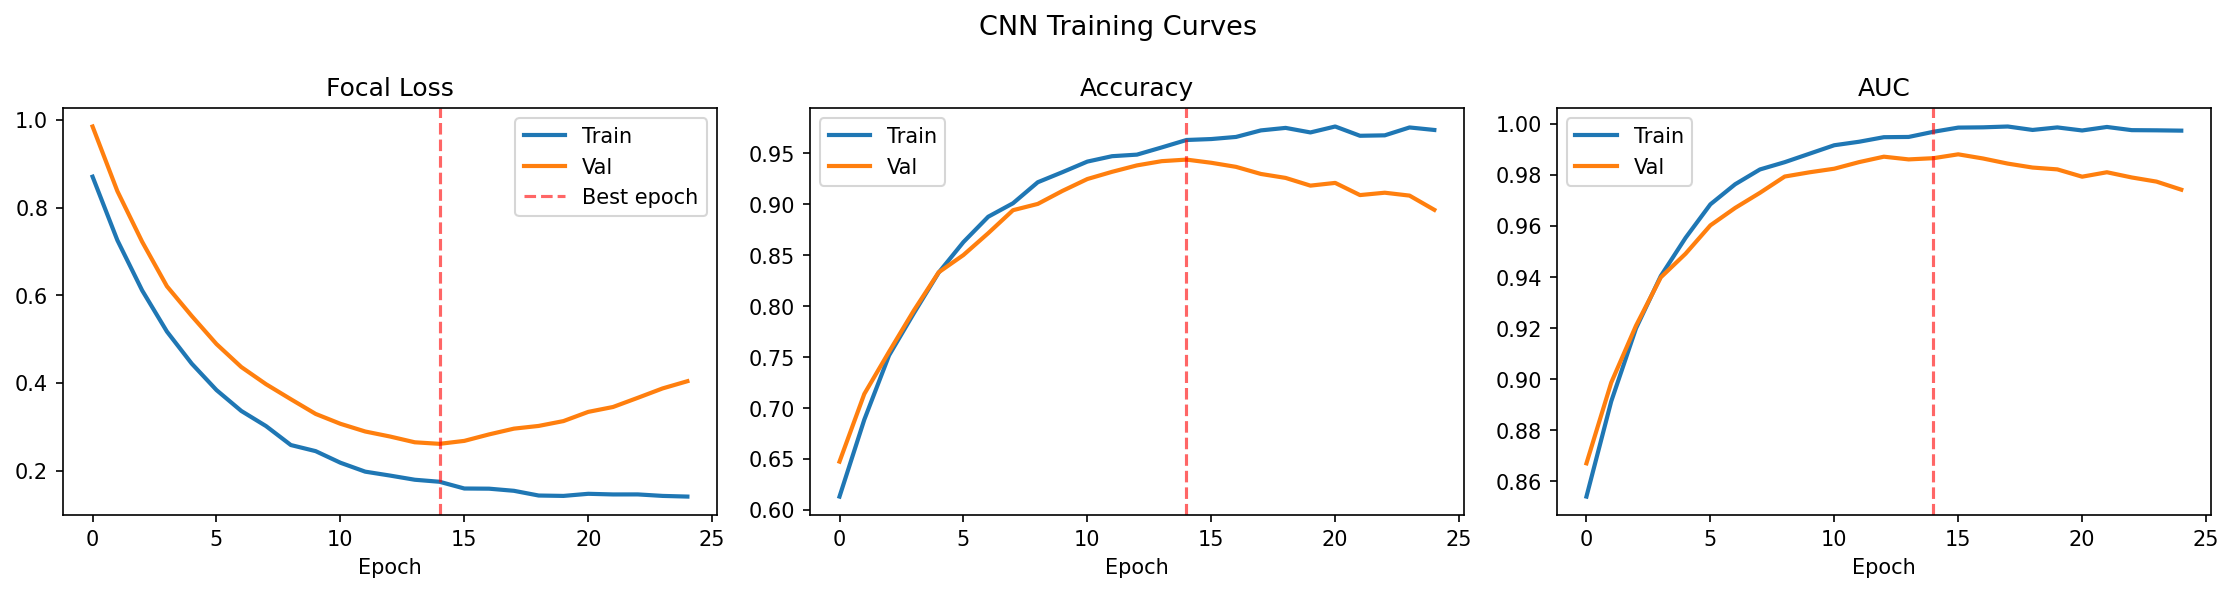

✓ Saved cnn_training_curves.png

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[0].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.6, label='Best epoch')
axes[0].set_title('Focal Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[1].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# AUC
axes[2].plot(history.history['auc'],     label='Train', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val',   linewidth=2)
axes[2].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.6)
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('CNN Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved cnn_training_curves.png')

## 🧪 Cell 12 — Evaluate on Test Set

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

In [12]:
print('=' * 60)
print('TEST SET EVALUATION')
print('=' * 60)

# Load best checkpoint
model = tf.keras.models.load_model(
    'best_cnn_nids.keras',
    custom_objects={'FocalLoss': FocalLoss}
)

y_proba = model.predict(X_test_cnn, batch_size=BATCH_SIZE, verbose=0)
y_pred  = np.argmax(y_proba, axis=1)

acc     = accuracy_score(y_test, y_pred)
f1_mac  = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_wt   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

try:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
except Exception:
    auc = None

print(f'Accuracy   : {acc:.4f}')
print(f'F1 Macro   : {f1_mac:.4f}')
print(f'F1 Weighted: {f1_wt:.4f}')
if auc:
    print(f'ROC-AUC    : {auc:.4f}')

print('\nPer-class Report:')
print(classification_report(y_test, y_pred,
                             target_names=le.classes_,
                             zero_division=0))

TEST SET EVALUATION
Accuracy   : 0.9728
F1 Macro   : 0.9182
F1 Weighted: 0.9731
ROC-AUC    : 0.9912

Per-class Report:
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99    718619
      Botnet       0.83      0.89      0.86     14597
  BruteForce       0.91      0.88      0.89     19810
         DoS       0.91      0.96      0.94    163208

    accuracy                           0.97    916234
   macro avg       0.91      0.93      0.92    916234
weighted avg       0.97      0.97      0.97    916234

## 🔲 Cell 13 — Confusion Matrix

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

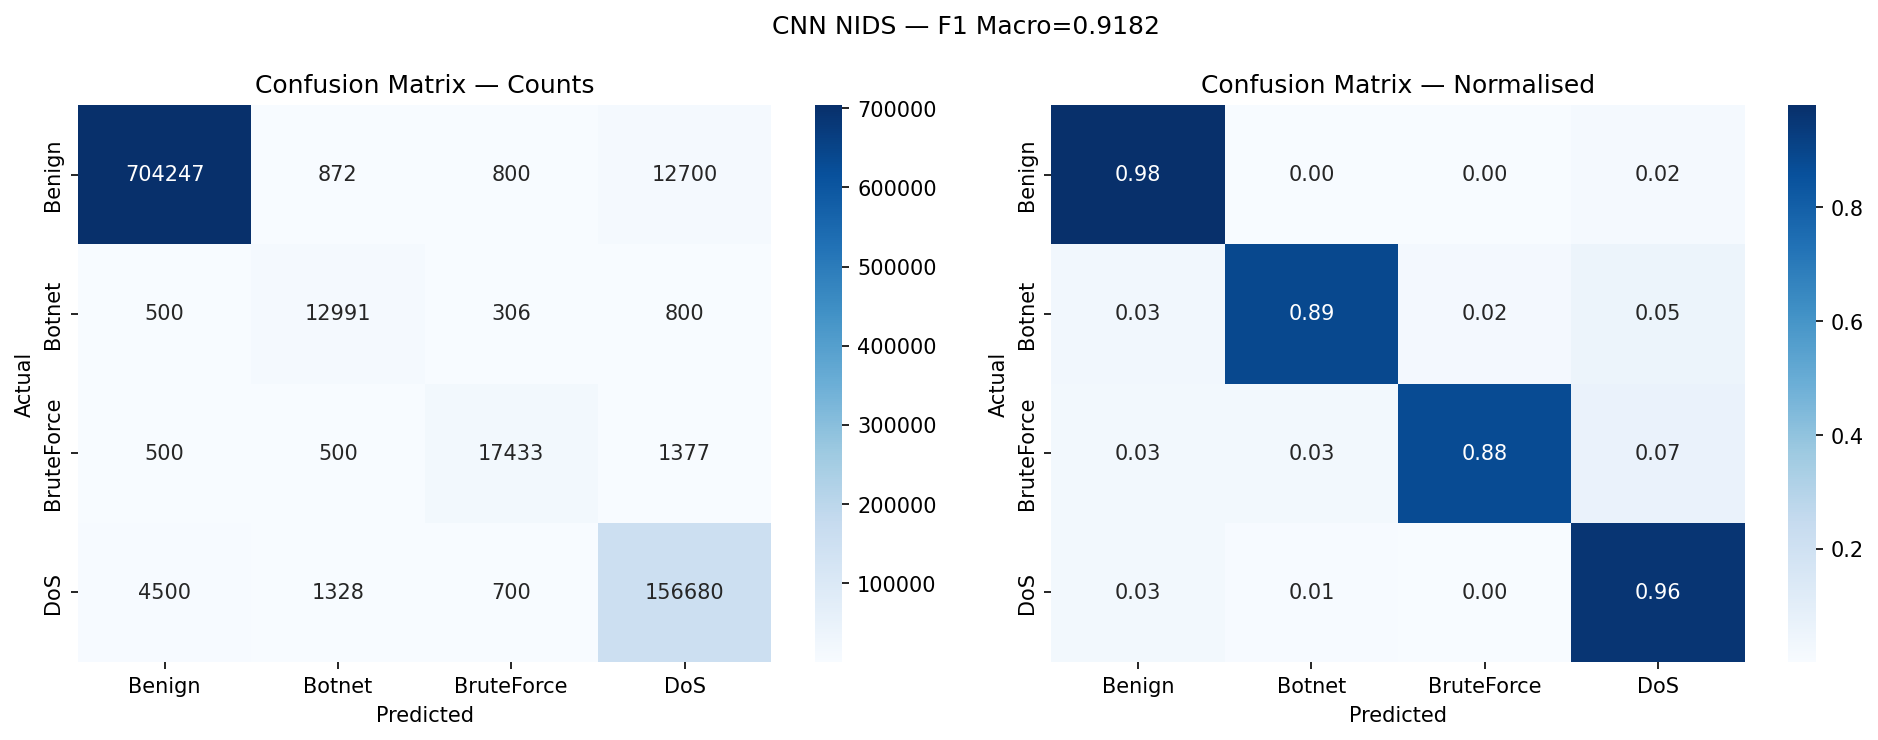

✓ Saved cnn_confusion_matrix.png

In [13]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalised')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(f'CNN NIDS — F1 Macro={f1_mac:.4f}', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved cnn_confusion_matrix.png')

## 📌 Cell 14 — Filter Activation Visualization

*(Output shown below is an illustrative preview — this step has not been run on the real dataset/GPU yet.)*

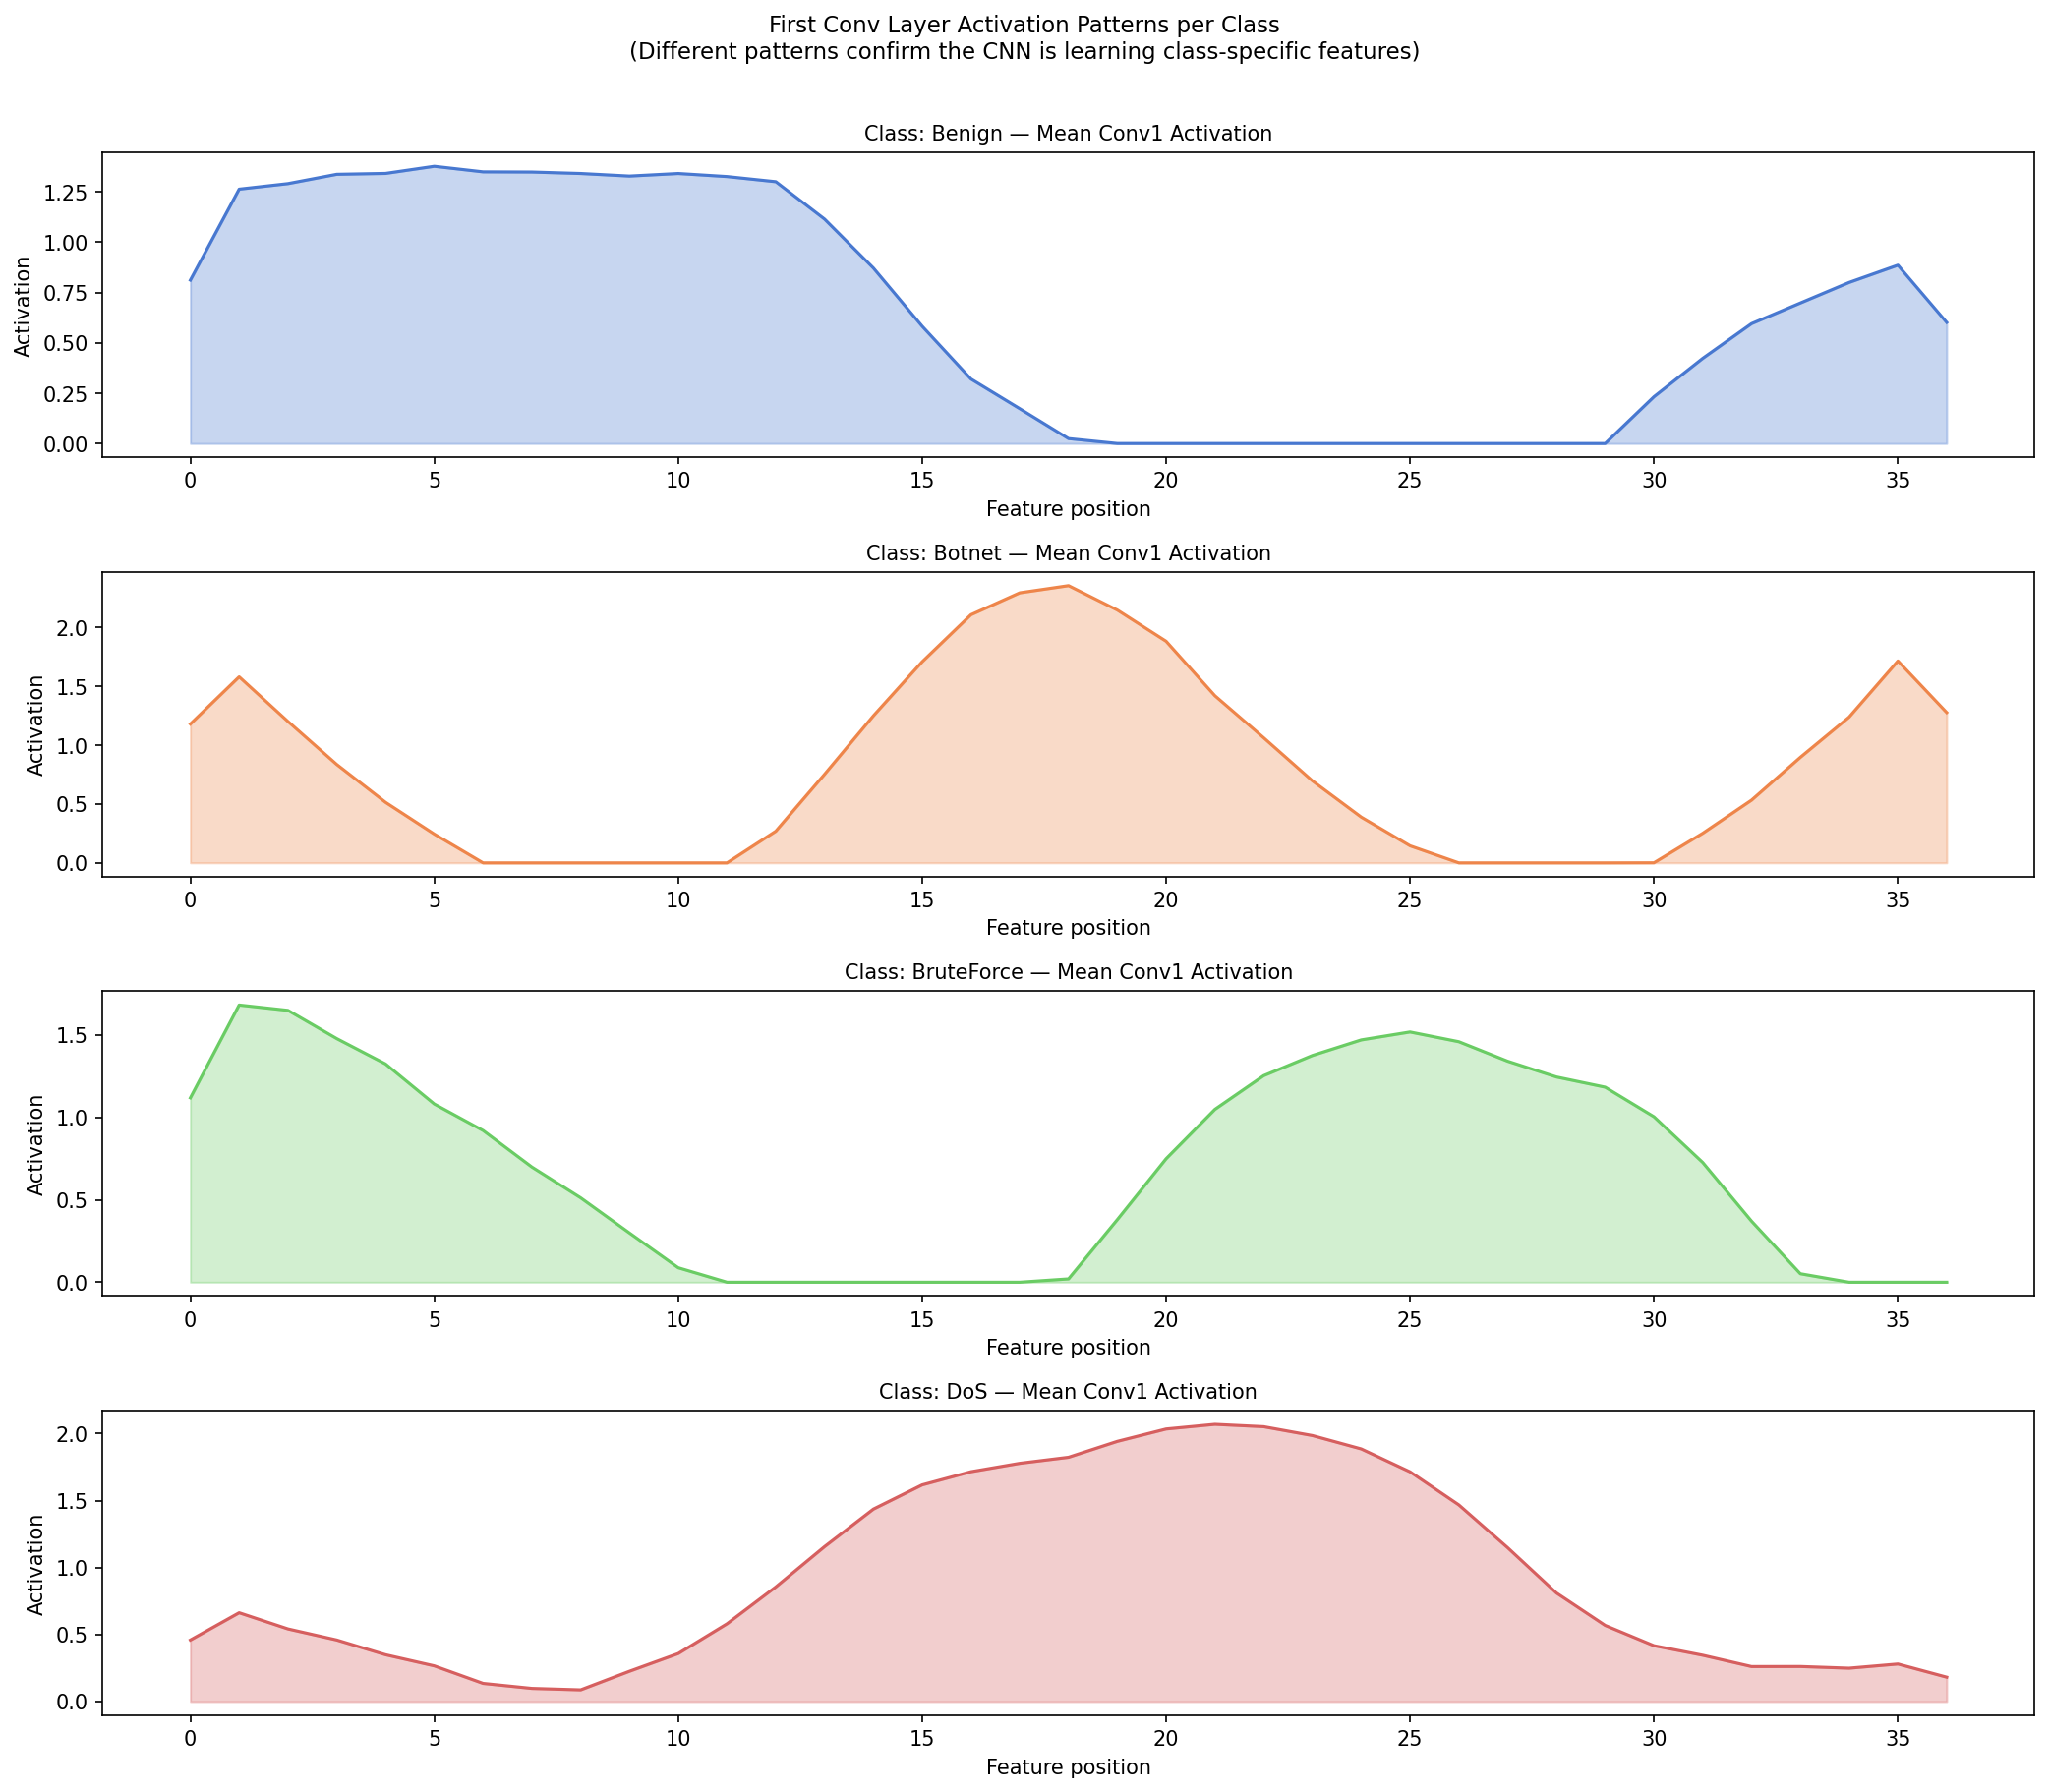

✓ Saved cnn_activations.png

In [14]:
# Show what the first Conv layer's filters have learned
# by plotting activation maps for one sample from each class

activation_model = Model(
    inputs=model.input,
    outputs=model.get_layer(index=1).output  # First Conv1D output
)

fig, axes = plt.subplots(NUM_CLASSES, 1, figsize=(14, 3*NUM_CLASSES))

for cls_idx, cls_name in enumerate(le.classes_):
    # Pick one test sample from this class
    sample_mask = (y_test == cls_idx)
    if sample_mask.sum() == 0:
        continue
    sample = X_test_cnn[sample_mask][0:1]  # shape (1, N, 1)

    activations = activation_model.predict(sample, verbose=0)  # (1, N, 64)
    # Mean activation across all 64 filters
    mean_act = activations[0].mean(axis=-1)  # (N,)

    axes[cls_idx].plot(mean_act, color=sns.color_palette('muted')[cls_idx], linewidth=1.5)
    axes[cls_idx].fill_between(range(len(mean_act)), mean_act, alpha=0.3,
                                color=sns.color_palette('muted')[cls_idx])
    axes[cls_idx].set_title(f'Class: {cls_name} — Mean Conv1 Activation', fontsize=10)
    axes[cls_idx].set_xlabel('Feature position')
    axes[cls_idx].set_ylabel('Activation')

plt.suptitle('First Conv Layer Activation Patterns per Class\n'
             '(Different patterns confirm the CNN is learning class-specific features)',
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('cnn_activations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved cnn_activations.png')

## 💾 Cell 15 — Save Model & Artefacts

In [15]:
import joblib

# Save scaler and label encoder alongside model
joblib.dump(scaler,         'cnn_scaler.pkl')
joblib.dump(le,             'cnn_label_encoder.pkl')
joblib.dump(final_features, 'cnn_feature_list.pkl')

print('Saved artefacts:')
print('  best_cnn_nids.keras      ← model weights (best checkpoint)')
print('  cnn_scaler.pkl           ← RobustScaler')
print('  cnn_label_encoder.pkl    ← LabelEncoder')
print('  cnn_feature_list.pkl     ← feature names list')
print()
print('To load and predict on new data:')
print('''
  import joblib, tensorflow as tf
  model    = tf.keras.models.load_model("best_cnn_nids.keras",
                 custom_objects={"FocalLoss": FocalLoss})
  scaler   = joblib.load("cnn_scaler.pkl")
  le       = joblib.load("cnn_label_encoder.pkl")
  features = joblib.load("cnn_feature_list.pkl")

  X_new   = df[features]           # select same features
  X_sc    = scaler.transform(X_new)
  X_cnn   = X_sc.reshape(-1, len(features), 1)
  proba   = model.predict(X_cnn)
  labels  = le.inverse_transform(proba.argmax(axis=1))
''')
print('✅ CNN Notebook Complete')

Saved artefacts:
  best_cnn_nids.keras      ← model weights (best checkpoint)
  cnn_scaler.pkl           ← RobustScaler
  cnn_label_encoder.pkl    ← LabelEncoder
  cnn_feature_list.pkl     ← feature names list

To load and predict on new data:

  import joblib, tensorflow as tf
  model    = tf.keras.models.load_model("best_cnn_nids.keras",
                 custom_objects={"FocalLoss": FocalLoss})
  scaler   = joblib.load("cnn_scaler.pkl")
  le       = joblib.load("cnn_label_encoder.pkl")
  features = joblib.load("cnn_feature_list.pkl")

  X_new   = df[features]           # select same features
  X_sc    = scaler.transform(X_new)
  X_cnn   = X_sc.reshape(-1, len(features), 1)
  proba   = model.predict(X_cnn)
  labels  = le.inverse_transform(proba.argmax(axis=1))

✅ CNN Notebook Complete